In [6]:
import numpy as np
import pandas as pd

file_1 ='/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step1_NetworkHierarchy/INT_DiffNetwork/subtype2_DiffNetwork_flattened.csv'
file_2 ='/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step8_FirstEp_Diff/subtype2_FirstEp.csv'
#file_1 = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype2_FirstEp.csv'
#Read the CSV files into DataFrames
df1 = pd.read_csv(file_1)
df2 = pd.read_csv(file_2)

df_new = pd.merge(df2, df1, on='subID', how='inner')
df_new.to_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step1_NetworkHierarchy/INT_DiffNetwork/DiffNetwork_FirstEp_ classify/subtype2_DiffNetwork_FirstEp.csv', index=False,encoding='utf-8-sig')

In [34]:
import pandas as pd
import numpy as np
from scipy.io import savemat
df_new = pd.read_csv('//Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step1_NetworkHierarchy/INT_DiffNetwork/PLSC/subtype1_DiffNetwork_HAMD_zero.csv')
print(df_new)
data = np.array(df_new.iloc[:, 1:])
savemat('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step1_NetworkHierarchy/INT_DiffNetwork/PLSC/subtype1_DiffNetwork_HAMD_zero.mat', {'data': data})

               subID  age  sex   mean_fd  Default-Frontoparietal  \
0         sub-MDD060   38    1  0.029830                0.016454   
1         sub-MDD083   30    2  0.041014               -0.231295   
2    sub-01000504V01   26    1  0.042903               -0.101241   
3    sub-01000012V01   28    2  0.043518                0.144463   
4    sub-01000286V01   33    2  0.044620               -0.100297   
..               ...  ...  ...       ...                     ...   
136       sub-MDD035   23    2  0.153265               -0.010233   
137       sub-MDD044   32    1  0.168524                0.194753   
138       sub-MDD027   31    2  0.176016                0.281418   
139  sub-01000533V01   31    1  0.176900                0.524200   
140  sub-01000660V01   40    1  0.184888               -0.323672   

     Default-Limbic  Default-Ventral_Attention  Default-Dorsal_Attention  \
0          0.372998                   0.176150                  0.247453   
1          0.160933            

Step -1 subcortical 画图

In [12]:
import pandas as pd
import nibabel as nib
import numpy as np
import os
'''
    此代码得到 subcortical 的 Volume 数据（.nii）之后可用于画图（subcortical_nilearn.py画图）。无卡阈值！！！
'''

def process_brain_data(value_csv, label_csv, template_nii, output_full_nii, output_subcortical_nii):
    """
    整合处理函数：
    1. 读取 CSV 数据并匹配到 Brainnetome Atlas。
    2. 生成全脑 NIfTI 文件。
    3. 基于全脑数据，剔除皮层区域（Label < 211），生成仅含皮层下的 NIfTI 文件。
    """
    print(f"--- 开始处理流水线 ---")

    # ==========================================
    # 第一步：读取数据与建立映射
    # ==========================================
    print("1. [读取] 正在读取数据文件...")
    df_values = pd.read_csv(value_csv)
    df_labels = pd.read_csv(label_csv)

    # 获取指标值（取第一行）
    mean_values = df_values.iloc[0]

    data_columns = df_values.columns.tolist()

    # 建立 [Label ID] -> [指标值] 的字典
    id_to_value_map = {}
    missing_regions = []

    print("   正在匹配脑区名称与 Label ID...")
    for index, row in df_labels.iterrows():
        label_id = row['Label']
        region_name = str(row['regions'])

        target_val = None
        # 匹配逻辑
        if region_name in data_columns:
            target_val = mean_values[region_name]
        else:
            if '/' in region_name:
                short_name = region_name.split('/')[-1]
                if short_name in data_columns:
                    target_val = mean_values[short_name]

        if target_val is not None:
            id_to_value_map[label_id] = target_val   # 构建字段，label:mean value
            print(id_to_value_map)

        else:
            missing_regions.append(region_name)

    print(f"   匹配完成: 成功 {len(id_to_value_map)} 个, 失败 {len(missing_regions)} 个。")

    # ==========================================
    # 第二步：生成全脑数据矩阵
    # ==========================================
    print(f"2. [全脑] 正在读取模板并填入数据: {template_nii}")
    atlas_img = nib.load(template_nii)
    atlas_data = atlas_img.get_fdata()

    # 创建全脑数据数组 (float32)
    full_data = np.zeros(atlas_data.shape, dtype=np.float32)


    # 填入数据
    for label_id, val in id_to_value_map.items():
        full_data[atlas_data == label_id] = val

    # 保存全脑 NIfTI 文件
    full_img = nib.Nifti1Image(full_data, atlas_img.affine, atlas_img.header)
    full_img.header.set_data_dtype(np.float32)

    print(f"   正在保存全脑结果到: {output_full_nii}")
    nib.save(full_img, output_full_nii)

    # ==========================================
    # 第三步：生成仅皮层下数据 (Subcortical Only)
    # ==========================================
    print("3. [皮层下] 正在剔除皮层数据 (保留 Label 211-246)...")

    # 直接复制刚才生成的全脑数据，无需重新加载
    subcortical_data = full_data.copy()

    # 核心逻辑：找到 Label < 211 且不为背景(0) 的区域 -> 设为 0
    mask_cortex = (atlas_data < 211) & (atlas_data > 0)
    subcortical_data[mask_cortex] = 0

    # 确保背景也是 0
    subcortical_data[atlas_data == 0] = 0

    # 保存皮层下 NIfTI 文件
    subc_img = nib.Nifti1Image(subcortical_data, atlas_img.affine, atlas_img.header)
    subc_img.header.set_data_dtype(np.float32)

    print(f"   正在保存仅含皮层下的结果到: {output_subcortical_nii}")
    nib.save(subc_img, output_subcortical_nii)

    print("--- 全部处理完成 ---")


# ==========================================
# 在这里配置你的文件路径
# ==========================================

# 输入文件

input_label_csv = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv'
input_template = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_246_2mm.nii.gz'


path = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step5_HAMD_Prediction/"
#修改一下路径
input_value_csv = os.path.join(path, "PLSR_true_pred.csv")
# 输出文件
output_full_file = os.path.join(path, "s2_Brain_Groupmean.nii")
output_subc_file = os.path.join(path, "s2_subcotical_GroupmeanINT.nii")

if __name__ == '__main__':

        process_brain_data(
            input_value_csv,
            input_label_csv,
            input_template,
            output_full_file,
            output_subc_file
        )


--- 开始处理流水线 ---
1. [读取] 正在读取数据文件...
   正在匹配脑区名称与 Label ID...
   匹配完成: 成功 0 个, 失败 246 个。
2. [全脑] 正在读取模板并填入数据: /Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_246_2mm.nii.gz
   正在保存全脑结果到: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step5_HAMD_Prediction/s2_Brain_Groupmean.nii
3. [皮层下] 正在剔除皮层数据 (保留 Label 211-246)...
   正在保存仅含皮层下的结果到: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step5_HAMD_Prediction/s2_subcotical_GroupmeanINT.nii
--- 全部处理完成 ---


In [23]:
import pandas as pd
import nibabel as nib
import numpy as np
import os

'''
    此代码得到 subcortical 的 Volume 数据（.nii）之后可用于画图（subcortical_nilearn.py画图）。
    【修改版】：读取统计表格，仅将 fdr-pvalue <= 0.05 且显著的 t 值映射到脑图上！ 卡阈值版本！！！
'''

def process_brain_data(stat_csv, label_csv, template_nii, output_full_nii, output_subcortical_nii):
    """
    整合处理函数：
    1. 读取包含 tvalue 和 fdr-pvalue 的统计 CSV 数据，并匹配到 Brainnetome Atlas。
    2. 生成全脑 NIfTI 文件（仅显著区域有 t 值，其余为 0）。
    3. 基于全脑数据，剔除皮层区域（Label < 211），生成仅含皮层下的 NIfTI 文件。
    """
    print(f"--- 开始处理流水线 ---")

    # ==========================================
    # 第一步：读取数据与建立映射
    # ==========================================
    print("1. [读取] 正在读取统计数据与标签文件...")
    df_stat = pd.read_csv(stat_csv)
    df_labels = pd.read_csv(label_csv)

    # 将统计表格转换为以 ROI 为键的字典，方便快速查询
    # 结构形如: {'A8m_L': {'tvalue': -11.01, 'pvalue': 2.97e-24, 'fdr-pvalue': 3.52e-23}, ...}
    stat_dict = df_stat.set_index('ROI').to_dict('index')

    # 建立 [Label ID] -> [tvalue] 的字典
    id_to_value_map = {}
    missing_regions = []
    non_sig_regions = []

    print("   正在匹配脑区名称、判断显著性并提取 T 值...")
    for index, row in df_labels.iterrows():
        label_id = row['Label']
        region_name = str(row['regions'])

        target_roi = None
        # 匹配逻辑
        if region_name in stat_dict:
            target_roi = region_name
        else:
            if '/' in region_name:
                short_name = region_name.split('/')[-1]
                if short_name in stat_dict:
                    target_roi = short_name

        if target_roi is not None:
            # 获取对应的 FDR p 值和 t 值
            fdr_p = stat_dict[target_roi]['fdr-pvalue']
            t_val = stat_dict[target_roi]['tvalue']

            # 判断是否显著
            if fdr_p <= 0.05:
                id_to_value_map[label_id] = t_val
            else:
                non_sig_regions.append(region_name)
        else:
            missing_regions.append(region_name)

    print(f"   匹配完成:")
    print(f"     - 成功匹配且 FDR 显著 (<=0.05): {len(id_to_value_map)} 个脑区")
    print(f"     - 成功匹配但不显著 (>0.05): {len(non_sig_regions)} 个脑区")
    print(f"     - 未能在统计表中找到: {len(missing_regions)} 个脑区")

    # ==========================================
    # 第二步：生成全脑数据矩阵
    # ==========================================
    print(f"2. [全脑] 正在读取模板并填入数据: {template_nii}")
    atlas_img = nib.load(template_nii)
    atlas_data = atlas_img.get_fdata()

    # 创建全脑数据数组 (float32)，默认全部为 0（代表背景或不显著）
    full_data = np.zeros(atlas_data.shape, dtype=np.float32)

    # 填入显著的 t 值数据
    for label_id, val in id_to_value_map.items():
        full_data[atlas_data == label_id] = val

    # 保存全脑 NIfTI 文件
    full_img = nib.Nifti1Image(full_data, atlas_img.affine, atlas_img.header)
    full_img.header.set_data_dtype(np.float32)

    print(f"   正在保存全脑显著性 T 值结果到: {output_full_nii}")
    nib.save(full_img, output_full_nii)

    # ==========================================
    # 第三步：生成仅皮层下数据 (Subcortical Only)
    # ==========================================
    print("3. [皮层下] 正在剔除皮层数据 (保留 Label 211-246)...")

    # 直接复制刚才生成的全脑数据，无需重新加载
    subcortical_data = full_data.copy()

    # 核心逻辑：找到 Label < 211 且不为背景(0) 的区域 -> 设为 0
    mask_cortex = (atlas_data < 211) & (atlas_data > 0)
    subcortical_data[mask_cortex] = 0

    # 确保背景也是 0
    subcortical_data[atlas_data == 0] = 0

    # 保存皮层下 NIfTI 文件
    subc_img = nib.Nifti1Image(subcortical_data, atlas_img.affine, atlas_img.header)
    subc_img.header.set_data_dtype(np.float32)

    print(f"   正在保存仅含皮层下的显著性 T 值结果到: {output_subcortical_nii}")
    nib.save(subc_img, output_subcortical_nii)

    print("--- 全部处理完成 ---")


# ==========================================
# 在这里配置你的文件路径
# ==========================================

# 基础目录
path = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step2_BNA246INT_Ttest/"
# 输入文件
input_label_csv = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv'
input_template = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_246_2mm.nii.gz'

# 【修改】指向你新的统计结果表格
input_stat_csv = os.path.join(path, "Ttest_Region_Subtype2vsHC_GLM.csv")

# 输出文件
output_full_file = os.path.join(path, "Ttest_Sub2vsHC_Tvalue.nii")
output_subc_file = os.path.join(path, "subcotical_Ttest_Sub2vsHC_Tvalue.nii")

if __name__ == '__main__':
    process_brain_data(
        input_stat_csv,
        input_label_csv,
        input_template,
        output_full_file,
        output_subc_file
    )

--- 开始处理流水线 ---
1. [读取] 正在读取统计数据与标签文件...
   正在匹配脑区名称、判断显著性并提取 T 值...
   匹配完成:
     - 成功匹配且 FDR 显著 (<=0.05): 238 个脑区
     - 成功匹配但不显著 (>0.05): 8 个脑区
     - 未能在统计表中找到: 0 个脑区
2. [全脑] 正在读取模板并填入数据: /Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_246_2mm.nii.gz
   正在保存全脑显著性 T 值结果到: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step2_BNA246INT_Ttest/Ttest_Sub2vsHC_Tvalue.nii
3. [皮层下] 正在剔除皮层数据 (保留 Label 211-246)...
   正在保存仅含皮层下的显著性 T 值结果到: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step2_BNA246INT_Ttest/subcotical_Ttest_Sub2vsHC_Tvalue.nii
--- 全部处理完成 ---


震源中心的 r值映射到皮层下

In [1]:
import pandas as pd
import nibabel as nib
import numpy as np
import os

'''
    此代码得到 subcortical 的 Volume 数据（.nii）之后可用于画图。
    【Epicenter 修改版】：读取 Epicenter 表格，仅将 Significant == 'Yes' 且显著的 r 值映射到脑图上！
'''

def process_brain_data(stat_csv, label_csv, template_nii, output_full_nii, output_subcortical_nii):
    """
    整合处理函数：
    1. 读取包含 Epicenter_r 和 Significant 的 CSV 数据，并匹配到 Brainnetome Atlas。
    2. 生成全脑 NIfTI 文件（仅显著区域有 r 值，其余为 0）。
    3. 基于全脑数据，剔除皮层区域（Label < 211），生成仅含皮层下的 NIfTI 文件。
    """
    print(f"--- 开始处理流水线 ---")

    # ==========================================
    # 第一步：读取数据与建立映射
    # ==========================================
    print("1. [读取] 正在读取统计数据与标签文件...")
    df_stat = pd.read_csv(stat_csv)
    df_labels = pd.read_csv(label_csv)

    # 【修改】：新表格的脑区列名为 'Region'
    # 转换为字典，结构形如: {'34_L': {'Epicenter_r': -0.244, 'p_surrogate': 0.011, 'Significant': 'Yes'}, ...}
    stat_dict = df_stat.set_index('Region').to_dict('index')

    # 建立 [Label ID] -> [r 值] 的字典
    id_to_value_map = {}
    missing_regions = []
    non_sig_regions = []

    print("   正在匹配脑区名称、判断显著性并提取 r 值...")
    for index, row in df_labels.iterrows():
        label_id = row['Label']
        region_name = str(row['regions'])

        target_roi = None
        # 匹配逻辑
        if region_name in stat_dict:
            target_roi = region_name
        else:
            if '/' in region_name:
                short_name = region_name.split('/')[-1]
                if short_name in stat_dict:
                    target_roi = short_name

        if target_roi is not None:
            # 【修改】：获取对应的 r 值和显著性标记
            r_val = stat_dict[target_roi]['Epicenter_r']
            is_sig = stat_dict[target_roi]['Significant']

            # 【修改】：判断是否显著 (依据 Significant 列的值为 'Yes')
            if str(is_sig).strip().lower() == 'yes':
                id_to_value_map[label_id] = r_val
            else:
                non_sig_regions.append(region_name)
        else:
            missing_regions.append(region_name)

    print(f"   匹配完成:")
    print(f"     - 成功匹配且显著 (Significant='Yes'): {len(id_to_value_map)} 个脑区")
    print(f"     - 成功匹配但不显著 (Significant='No'): {len(non_sig_regions)} 个脑区")
    print(f"     - 未能在统计表中找到: {len(missing_regions)} 个脑区")

    # ==========================================
    # 第二步：生成全脑数据矩阵
    # ==========================================
    print(f"2. [全脑] 正在读取模板并填入数据: {template_nii}")
    atlas_img = nib.load(template_nii)
    atlas_data = atlas_img.get_fdata()

    # 创建全脑数据数组 (float32)，默认全部为 0（代表背景或不显著）
    full_data = np.zeros(atlas_data.shape, dtype=np.float32)

    # 填入显著的 r 值数据
    for label_id, val in id_to_value_map.items():
        full_data[atlas_data == label_id] = val

    # 保存全脑 NIfTI 文件
    full_img = nib.Nifti1Image(full_data, atlas_img.affine, atlas_img.header)
    full_img.header.set_data_dtype(np.float32)

    print(f"   正在保存全脑显著性 r 值结果到: {output_full_nii}")
    nib.save(full_img, output_full_nii)

    # ==========================================
    # 第三步：生成仅皮层下数据 (Subcortical Only)
    # ==========================================
    print("3. [皮层下] 正在剔除皮层数据 (保留 Label 211-246)...")

    # 直接复制刚才生成的全脑数据，无需重新加载
    subcortical_data = full_data.copy()

    # 核心逻辑：找到 Label < 211 且不为背景(0) 的区域 -> 设为 0
    mask_cortex = (atlas_data < 211) & (atlas_data > 0)
    subcortical_data[mask_cortex] = 0

    # 确保背景也是 0
    subcortical_data[atlas_data == 0] = 0

    # 保存皮层下 NIfTI 文件
    subc_img = nib.Nifti1Image(subcortical_data, atlas_img.affine, atlas_img.header)
    subc_img.header.set_data_dtype(np.float32)

    print(f"   正在保存仅含皮层下的显著性 r 值结果到: {output_subcortical_nii}")
    nib.save(subc_img, output_subcortical_nii)

    print("--- 全部处理完成 ---")


# ==========================================
# 在这里配置你的文件路径
# ==========================================

# 基础目录
path = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step16_Epicenters/"
# 输入文件
input_label_csv = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv'
input_template = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_246_2mm.nii.gz'

# 【修改】指向你上传的 Epicenters 表格
input_stat_csv = os.path.join(path, "subtype1_FullBrain_Epicenters_BrainSMASH2.csv")

# 输出文件 (更改后缀名称以表示 r 值)
output_full_file = os.path.join(path, "Subtype1_Epicenter_Rvalue_FullBrain.nii")
output_subc_file = os.path.join(path, "Subtype1_Epicenter_Rvalue_Subcortical.nii")

if __name__ == '__main__':
    process_brain_data(
        input_stat_csv,
        input_label_csv,
        input_template,
        output_full_file,
        output_subc_file
    )

--- 开始处理流水线 ---
1. [读取] 正在读取统计数据与标签文件...
   正在匹配脑区名称、判断显著性并提取 r 值...
   匹配完成:
     - 成功匹配且显著 (Significant='Yes'): 9 个脑区
     - 成功匹配但不显著 (Significant='No'): 237 个脑区
     - 未能在统计表中找到: 0 个脑区
2. [全脑] 正在读取模板并填入数据: /Users/qingchen/Documents/Data/template/BrainnetomeAtlas/BN_Atlas_246_2mm.nii.gz
   正在保存全脑显著性 r 值结果到: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step16_Epicenters/Subtype1_Epicenter_Rvalue_FullBrain.nii
3. [皮层下] 正在剔除皮层数据 (保留 Label 211-246)...
   正在保存仅含皮层下的显著性 r 值结果到: /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step16_Epicenters/Subtype1_Epicenter_Rvalue_Subcortical.nii
--- 全部处理完成 ---


Step -2 subcortical 画图


In [3]:
import matplotlib.pyplot as plt
from nilearn import plotting
from nilearn import datasets
import os
plt.switch_backend('Agg')
path = "/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step16_Epicenters/"
# 设置文件路径
nii_file = os.path.join(path, "Subtype1_Epicenter_Rvalue_Subcortical.nii")

# 创建画布
fig = plt.figure(figsize=(15, 4), facecolor='white')

# 使用 plot_stat_map 绘制切片图
# display = plotting.plot_stat_map(
#     nii_file,
#     display_mode='z',        # 轴状面切片 (Axial)
#     cut_coords=[-18, -6, 7, 19],  # 对应你参考图中的 Z 轴坐标点
#     cmap='coolwarm',         # 使用发散型色图
#     symmetric_cbar=True,     # ⭐ 关键：强制 0 点为白色，并自动对称 vmin/vmax
#     colorbar=True,           # 显示颜色条
#     threshold=0.01,          # 阈值：低于此值的像素设为透明（可根据需要调整）
#     black_bg=False,          # 使用白色背景（符合论文排版）
#     annotate=True,           # 显示坐标标注 (L/R, z=...)
#     figure=fig
# )
# 加载高分辨率 (1mm) 的 MNI152 模板
template = datasets.load_mni152_template(resolution=1)
plotting.plot_stat_map(
    nii_file,
    bg_img=template,
    display_mode='z',
    cut_coords=[-10, 16],
    symmetric_cbar=True,
    cmap='coolwarm',
    dim=0.8,           # ⭐ 调整背景亮度 (-1 到 1)，负值增加对比度
    alpha=0.9,          # 让颜色稍微透明，露出背景结构
    black_bg=False,
    figure=fig,
    #vmin=0,
    vmax=0.02,
    annotate=False
)
savepath = os.path.join(path, "s1_Epicenter_Rvalue_Subcortical.png")
# 保存图片
plt.savefig(savepath, dpi=300, bbox_inches='tight')
plt.show()

/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_13631/1328623574.py:28: UserWarning: kwargs['alpha']=0.9 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  plotting.plot_stat_map(
/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_13631/1328623574.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [20]:
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests # 导入多重比较校正模块

# 1. 读取匹配结果表，提取匹配后的 MDD 和 HC 的 subID
matched_df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/Match/Matched_Data_Result.csv')
mdd_subids = matched_df[matched_df['group'] == 1]['subID'].tolist()
hc_subids = matched_df[matched_df['group'] == 0]['subID'].tolist()

# 2. 读取对应组别的 8大网络数据表
mdd_7net = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/MDD_INT20_7net.csv')
hc_7net = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/HC_INT20_7net.csv')

# 3. 根据提取到的 subID 进行数据过滤 (即只保留匹配上的受试者)
mdd_data_matched = mdd_7net[mdd_7net['subID'].isin(mdd_subids)]
hc_data_matched = hc_7net[hc_7net['subID'].isin(hc_subids)]

print(f"参与分析的 MDD 样本量: {len(mdd_data_matched)}")
print(f"参与分析的 HC 样本量: {len(hc_data_matched)}\n")

# 4. 针对 8 个脑网络循环进行双样本 t 检验
networks = ['subcortical', 'Visual', 'Somatomotor', 'Dorsal_Attention',
            'Ventral_Attention', 'Limbic', 'Frontoparietal', 'Default']

results = []
raw_pvals = [] # 用于临时收集原始 p 值

for net in networks:
    if net in mdd_data_matched.columns and net in hc_data_matched.columns:
        mdd_vals = mdd_data_matched[net].dropna()
        hc_vals = hc_data_matched[net].dropna()

        # 4.1 方差齐性检验 (Levene's test)
        stat_lev, p_lev = stats.levene(mdd_vals, hc_vals)
        # 如果 p_lev > 0.05 则认为方差齐平，使用 Student's t-test；否则使用 Welch's t-test
        equal_var = True if p_lev > 0.05 else False

        # 4.2 独立双样本 t 检验
        t_stat, p_val = stats.ttest_ind(mdd_vals, hc_vals, equal_var=equal_var)

        raw_pvals.append(p_val) # 收集原始 p 值

        results.append({
            'Network': net,
            'MDD_Mean': mdd_vals.mean(),
            'MDD_Std': mdd_vals.std(),
            'HC_Mean': hc_vals.mean(),
            'HC_Std': hc_vals.std(),
            't_stat': t_stat,
            'p_value_raw': p_val # 记录原始 p 值
        })

# ================= 新增：FDR p值校正 =================
# method='fdr_bh' 代表使用 Benjamini/Hochberg FDR 校正方法
# 如果想用最严格的 Bonferroni，可以将 method 改为 'bonferroni'
reject, pvals_corrected, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')

# 将校正后的 p 值和最终的显著性星号添加回结果中
for i in range(len(results)):
    results[i]['p_value_FDR'] = pvals_corrected[i]
    # 基于校正后的 p 值判断显著性
    sig = '*' if pvals_corrected[i] < 0.05 else ('**' if pvals_corrected[i] < 0.01 else 'ns')
    results[i]['Significance(FDR)'] = sig

# 5. 格式化输出结果并保存为 CSV
results_df = pd.DataFrame(results)

# 打印美化后的 DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
print(results_df)

# 保存至本地
# results_df.to_csv('Matched_8Networks_TTest_FDR.csv', index=False)
print("\n结果已保存至 Matched_8Networks_TTest_FDR.csv")

参与分析的 MDD 样本量: 215
参与分析的 HC 样本量: 215

             Network  MDD_Mean  MDD_Std  HC_Mean  HC_Std  t_stat  p_value_raw  p_value_FDR Significance(FDR)
0        subcortical    3.2983   0.3253   3.3402  0.2599 -1.4786       0.1400       0.1866                ns
1             Visual    3.7051   0.3417   3.7729  0.3490 -2.0352       0.0424       0.1113                ns
2        Somatomotor    3.6447   0.4169   3.7153  0.3931 -1.8066       0.0715       0.1144                ns
3   Dorsal_Attention    3.7605   0.3420   3.8269  0.3504 -1.9892       0.0473       0.1113                ns
4  Ventral_Attention    3.6075   0.3971   3.6758  0.3393 -1.9191       0.0557       0.1113                ns
5             Limbic    3.4327   0.3347   3.4527  0.2994 -0.6519       0.5148       0.5148                ns
6     Frontoparietal    3.7939   0.3329   3.8366  0.3239 -1.3475       0.1785       0.2040                ns
7            Default    3.7480   0.3462   3.8141  0.3302 -2.0250       0.0435       0.1113

比较【健康人（HC）】和【抑郁症患者（MDD）】在 8 个大脑网络上的功能指标（INT）是否存在显著差异，并且已经排除年龄、性别带来的干扰

总样本数: 551 (HC: 215, MDD: 336)

=== 回归 Age/Sex 后 HC vs MDD t 检验结果 ===
             Network  HC_mean_adj  MDD_mean_adj      t  p_raw  Cohen_d  p_fdr  significant
7            Default       3.8148        3.7309 2.8890 0.0040   0.2500 0.0324         True
0        subcortical       3.3406        3.2827 2.3690 0.0182   0.1990 0.0332         True
1             Visual       3.7744        3.6963 2.6000 0.0096   0.2290 0.0332         True
3   Dorsal_Attention       3.8261        3.7569 2.2500 0.0249   0.1960 0.0332         True
4  Ventral_Attention       3.6715        3.5984 2.3140 0.0210   0.1950 0.0332         True
6     Frontoparietal       3.8386        3.7716 2.3290 0.0203   0.2010 0.0332         True
2        Somatomotor       3.7129        3.6442 1.9520 0.0515   0.1680 0.0589        False
5             Limbic       3.4523        3.4270 0.9300 0.3529   0.0790 0.3529        False


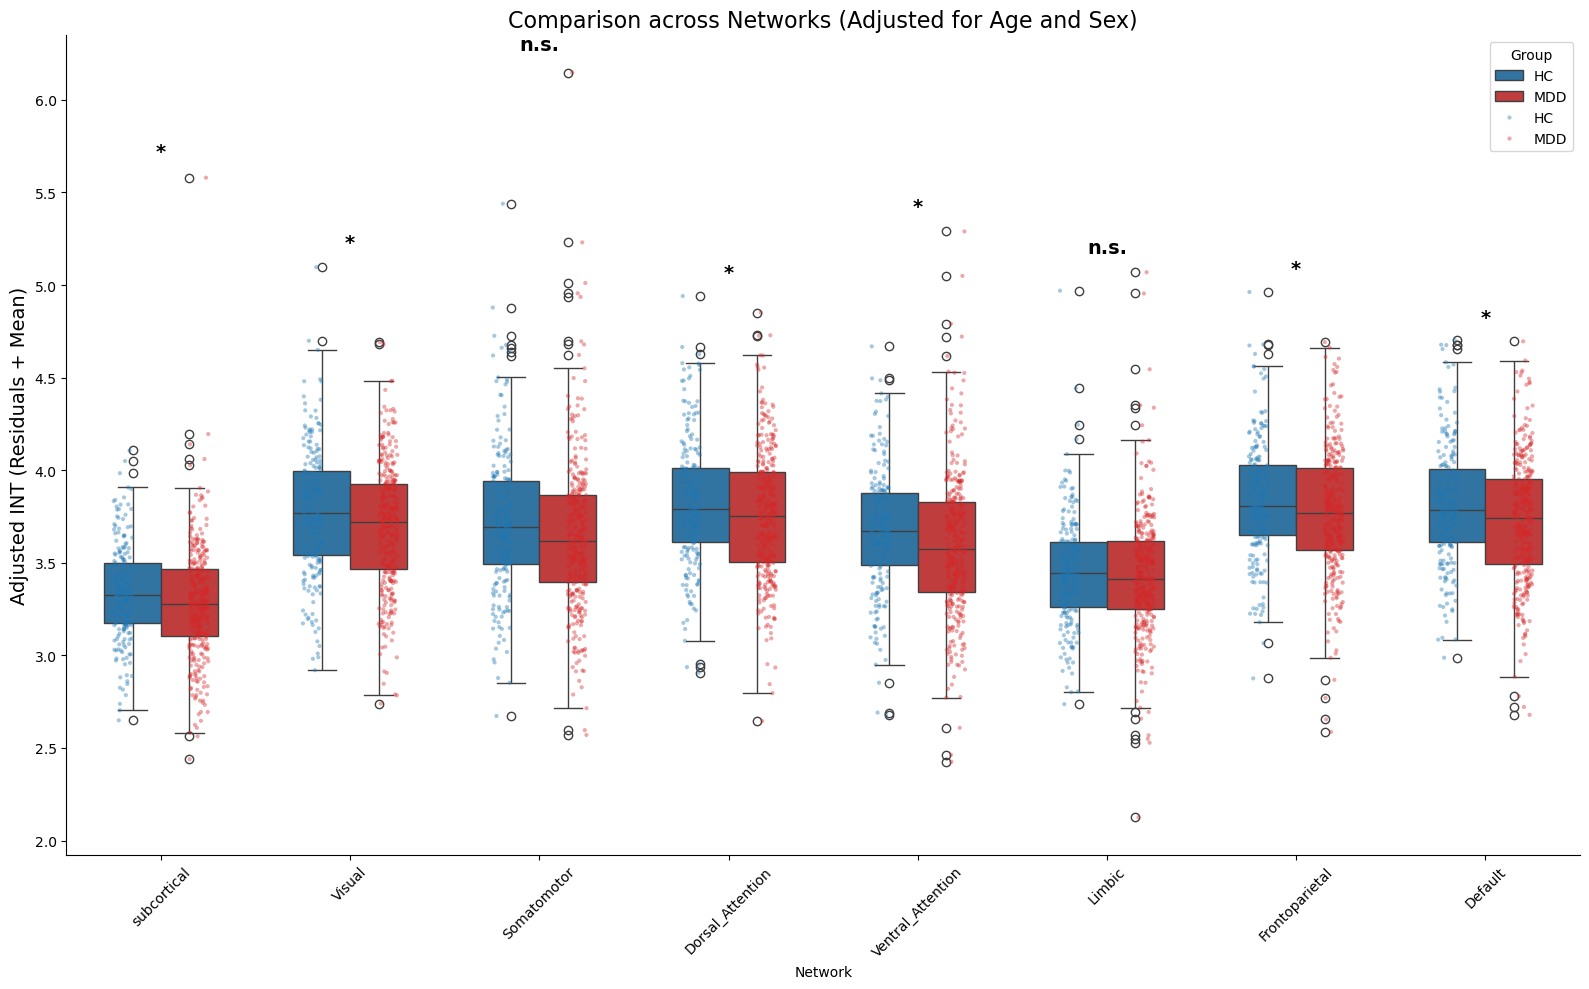

In [23]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# ================== 1. 读取数据 ==================
hc_df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/HC_INT20_7net_agesex.csv')
mdd_df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/MDD_INT20_7net_agesex.csv')

# 打标签并合并，方便统一回归处理
hc_df['Group'] = 'HC'
mdd_df['Group'] = 'MDD'
combined_df = pd.concat([hc_df, mdd_df], axis=0).reset_index(drop=True)

# 定义变量
networks = ['subcortical', 'Visual', 'Somatomotor', 'Dorsal_Attention',
            'Ventral_Attention', 'Limbic', 'Frontoparietal', 'Default']
covariates = ['age', 'sex'] # 确保列名与 CSV 中完全一致

print(f"总样本数: {len(combined_df)} (HC: {len(hc_df)}, MDD: {len(mdd_df)})")

# ================== 2. 回归去混淆 (Regress out Age & Sex) ==================
# 这里的逻辑是：基于全样本回归掉协变量，保留残差作为后续分析的输入
corrected_data = combined_df.copy()

for net in networks:
    # 准备回归数据，剔除缺失值
    mask = combined_df[[net] + covariates].notnull().all(axis=1)
    temp_df = combined_df[mask]

    X = temp_df[covariates]
    X = sm.add_constant(X) # 添加截距项
    y = temp_df[net]

    model = sm.OLS(y, X).fit()

    # 将残差存回原数据框（注意：残差会加上均值以保持数值量级的一致性，方便绘图）
    corrected_data.loc[mask, net] = model.resid + y.mean()

# ================== 3. 基于残差的双样本 t 检验 + FDR 校正 ==================
results = []

for net in networks:
    hc_res = corrected_data[corrected_data['Group'] == 'HC'][net].dropna()
    mdd_res = corrected_data[corrected_data['Group'] == 'MDD'][net].dropna()

    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(hc_res, mdd_res, equal_var=False)

    hc_mean, mdd_mean = hc_res.mean(), mdd_res.mean()
    hc_std, mdd_std = hc_res.std(), mdd_res.std()

    # Cohen's d
    pooled_std = np.sqrt(((len(hc_res)-1)*hc_std**2 + (len(mdd_res)-1)*mdd_std**2) / (len(hc_res)+len(mdd_res)-2))
    cohen_d = (hc_mean - mdd_mean) / pooled_std if pooled_std != 0 else 0

    results.append({
        'Network': net,
        'HC_mean_adj': round(hc_mean, 4),
        'MDD_mean_adj': round(mdd_mean, 4),
        't': round(t_stat, 3),
        'p_raw': p_val,
        'Cohen_d': round(cohen_d, 3)
    })

result_df = pd.DataFrame(results)
_, p_fdr = fdrcorrection(result_df['p_raw'], alpha=0.05)
result_df['p_fdr'] = p_fdr
result_df['significant'] = result_df['p_fdr'] < 0.05
result_df = result_df.sort_values('p_fdr')

print("\n=== 回归 Age/Sex 后 HC vs MDD t 检验结果 ===")
print(result_df)

# ================== 4. 绘图 (使用校正后的数据) ==================
plt.figure(figsize=(16, 10))

# 绘图
ax = sns.boxplot(x='Network', y='INT', hue='Group',
                 data=corrected_data.melt(id_vars='Group', value_vars=networks, var_name='Network', value_name='INT'),
                 palette={'HC': '#1f77b4', 'MDD': '#d62728'}, width=0.6)

sns.stripplot(x='Network', y='INT', hue='Group',
              data=corrected_data.melt(id_vars='Group', value_vars=networks, var_name='Network', value_name='INT'),
              dodge=True, alpha=0.4, jitter=True, size=3, palette={'HC': '#1f77b4', 'MDD': '#d62728'})

# 标注显著性 (根据 result_df)
for i, net in enumerate(networks):
    # 找到该网络对应的显著性
    p = result_df.loc[result_df['Network'] == net, 'p_fdr'].values[0]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

    y_max = corrected_data[net].max()
    plt.text(i, y_max * 1.02, sig, ha='center', fontsize=14, fontweight='bold')

plt.title('Comparison across Networks (Adjusted for Age and Sex)', fontsize=16)
plt.ylabel('Adjusted INT (Residuals + Mean)', fontsize=14)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

计算 HAMD17 的五个维度得分

In [15]:
import pandas as pd

# 1. 读取上传的数据
df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step12_HAMD5_Diff/subtype2_INT_HAMD_t.csv')

# 2. 根据指定的列计算五个维度的得分
# 第一维度：10、11、12、15列分数相加
df['Dimension_1'] = df['HAMD1710'] + df['HAMD1711'] + df['HAMD1712'] + df['HAMD1715']

# 第二维度：16列
df['Dimension_2'] = df['HAMD1716']

# 第三维度：2、3、9列分数相加
df['Dimension_3'] = df['HAMD1702'] + df['HAMD1703'] + df['HAMD1709']

# 第四维度：1、7、8、14列分数相加
df['Dimension_4'] = df['HAMD1701'] + df['HAMD1707'] + df['HAMD1708'] + df['HAMD1714']

# 第五维度：4、5、6列分数相加
df['Dimension_5'] = df['HAMD1704'] + df['HAMD1705'] + df['HAMD1706']

# 3. 将包含新维度列的数据保存到新的 CSV 文件中
output_file = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step12_HAMD5_Diff/subtype2_HAMD5_t.csv'
df.to_csv(output_file, index=False)

print("计算完成，结果已保存至：", output_file)

计算完成，结果已保存至： /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step12_HAMD5_Diff/subtype2_HAMD5_t.csv


In [24]:
import pandas as pd

# 读取数据
file_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step3_cGMVmean_Diff/subtype2_GMV246.csv'
df = pd.read_csv(file_path)

# 获取 'A8m_L' 列的索引
start_col_idx = df.columns.get_loc('A8m_R')

# 计算从 'A8m_L' 到最后一列的均值 (axis=1 表示按行计算)
df['mean_GMV'] = df.iloc[:, start_col_idx:].mean(axis=1)

# 将结果覆盖保存回原文件，index=False 防止保存时多出没用的索引列
df.to_csv(file_path, index=False)



In [28]:
import numpy as np
import pandas as pd

file_2='/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_BLR_HCMDD_250512/StaResults/MDD_ID.csv'
file_1 ='/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_BLR_HCMDD_250512/Feature/AllMDD_GrayVol_all246TIV_III.csv'
#file_1 = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype2_FirstEp.csv'
#Read the CSV files into DataFrames
df1 = pd.read_csv(file_1)
df2 = pd.read_csv(file_2)

df_new = pd.merge(df2, df1, on='subID', how='inner')
df_new.to_csv('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_BLR_HCMDD_250512/StaResults/MDD_ID.csv', index=False,encoding='utf-8-sig')

$r = 0.24$
$p = 0.02$


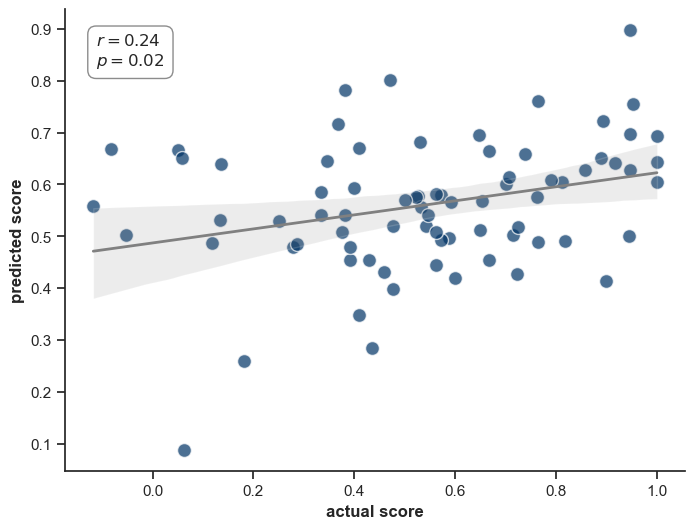

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. 读取 CSV 文件 (保留了您的本地绝对路径)
df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step5_HAMD_Prediction/PLSR_true_pred.csv')
x = df['y_true']
y = df['y_pred']

# 2. 自定义 r 和 p 值
r = 0.24
p = 0.02

# 3. 设置图表风格 (类似学术论文中干净的背景)
plt.figure(figsize=(8, 6))
sns.set_theme(style="ticks") # 使用带有刻度线的简洁风格

# 4. 使用 seaborn 的 regplot 绘制散点和带有置信区间的回归拟合线
# 【修改点】：将这里 scatter_kws 中的 's': 45 修改为了 's': 100，以增大散点大小
ax = sns.regplot(x=x, y=y,
                 scatter_kws={'alpha': 0.7, 'color': '#003366', 's': 100, 'edgecolor': 'w'},
                 line_kws={'color': 'gray', 'lw': 2})

# 5. 设置坐标轴标签
plt.xlabel('actual score', fontsize=12, fontweight='bold')
plt.ylabel('predicted score', fontsize=12, fontweight='bold')

# 6. 在图表中添加 r 和 p 值的文本框
# 格式化 r 和 p 的显示
if p < 0.001:
    textstr = f'$r = {r:.2f}$\n$p < 0.001$'
else:
    textstr = f'$r = {r:.2f}$\n$p = {p:.2f}$'
print(textstr)

# 文本框的样式
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')

# 将文本框放置在左上角 (x=0.05, y=0.95 是相对坐标)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

# 移除顶部和右侧的边框线，使图表更清爽
sns.despine()

# 7. 保存并显示 (保留了您的本地保存路径)
plt.savefig('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step5_HAMD_Prediction/scatter_regression_style.png', dpi=300, bbox_inches='tight')
# plt.show() # 如果在本地运行，取消注释以显示在此代码上进行修改

In [24]:
import pandas as pd
import scipy.stats as stats

# 1. 读取两组数据文件
df_mdd = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype2_INT_agesex_FD.csv')
df_hc = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/subtype1_INT_agesex_FD.csv')

# 2. 提取 mean_fd 列，并使用 dropna() 剔除可能存在的缺失值 (NaN)
fd_mdd = df_mdd['mean_fd'].dropna()
fd_hc = df_hc['mean_fd'].dropna()

# 3. 进行标准独立双样本 t 检验
# equal_var=True 表示假定两组数据方差齐性（即标准的 Student's t-test）
t_stat, p_val = stats.ttest_ind(fd_mdd, fd_hc, equal_var=True)

# 4. 打印结果
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.6f}")

# 如果需要根据 p 值输出结论，可以加上这段逻辑：
if p_val < 0.05:
    print("结论: 两组之间的平均头动存在显著差异 (p < 0.05)。")
else:
    print("结论: 两组之间的平均头动不存在显著差异 (p >= 0.05)。")

t-statistic: 2.6399
p-value: 0.008684
结论: 两组之间的平均头动存在显著差异 (p < 0.05)。


将组件 INT 差异的热力图从 246脑区，划分网络排列画出热图

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 加载数据
# ==========================================
# 替换为您本地的绝对路径
mat_df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step17_CovariationII/result1_EdgDiff/BetweenGroup_Significant_Network.csv', index_col=0)
yeo_df = pd.read_csv('/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv')

# ==========================================
# 2. 映射与重排 246 脑区顺序
# ==========================================
regions_in_mat = mat_df.columns.tolist()
yeo_df = yeo_df[yeo_df['regions'].isin(regions_in_mat)].copy()

# 将 0 标签 (皮层下) 和空值统一处理为 18，放在最后
yeo_df['Yeo_17network'] = yeo_df['Yeo_17network'].replace(0, 18).fillna(18)

# 按照 Yeo 网络编号排序
yeo_df_sorted = yeo_df.sort_values(by=['Yeo_17network', 'regions'])
ordered_regions = yeo_df_sorted['regions'].tolist()
mat_sorted = mat_df.loc[ordered_regions, ordered_regions]

# ==========================================
# 3. 计算网络标签位置与分隔边界
# ==========================================
network_counts = yeo_df_sorted['Yeo_17network'].value_counts(sort=False).sort_index()
boundaries = network_counts.cumsum().values[:-1]

# 计算每个网络的中心位置，用于放置标签
centers = []
start = 0
for count in network_counts:
    centers.append(start + count / 2)
    start += count

# 定义 17 网络名称 + 最后的 Subcortical
net_labels = [
    'VisCent', 'VisPeri', 'SomMotA', 'SomMotB', 'DorsAttnA', 'DorsAttnB',
    'SalVentAttnA', 'SalVentAttnB', 'LimbicA', 'LimbicB', 'ContA', 'ContB',
    'ContC', 'DefaultA', 'DefaultB', 'DefaultC', 'TempPar', 'Subcortical'
]

# ==========================================
# 4. 绘图
# ==========================================
fig, ax = plt.subplots(figsize=(16, 14), facecolor='white')

# 生成 mask
mask = np.triu(np.ones_like(mat_sorted, dtype=bool))
max_val = np.abs(mat_sorted.values).max()
if max_val == 0: max_val = 1

# 绘制热力图
sns.heatmap(mat_sorted,
            mask=mask,
            cmap="RdBu_r",
            center=0,
            vmin=-max_val,
            vmax=max_val,
            square=True,
            xticklabels=False,
            yticklabels=False,
            cbar_kws={"shrink": .8, "label": "Z-value (Subtype1 - Subtype2)"},
            ax=ax)

# 【核心修改 1】：强制遮挡区域及背景为白色
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# 【核心修改 2】：只在左下三角内部绘制网格线
# 我们遍历边界，但只画出对应长度的线，防止线穿过右上角
n = len(mat_sorted)
for b in boundaries:
    # 绘制水平虚线 (仅延伸到 b 的位置)
    ax.plot([0, b], [b, b], color='black', linewidth=0.5, linestyle=':')
    # 绘制垂直虚线 (仅从 b 到底部)
    ax.plot([b, b], [b, n], color='black', linewidth=0.5, linestyle=':')

# 添加网络标签
ax.set_xticks(centers)
ax.set_xticklabels(net_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(centers)
ax.set_yticklabels(net_labels, rotation=0, fontsize=9)

# 确保坐标轴边框为白色或透明，避免黑边干扰
for spine in ax.spines.values():
    spine.set_visible(False)

plt.title('Significant Structural Covariance Differences\n(Ordered by Yeo 17 Networks + Subcortical)', fontsize=18, pad=20)
plt.tight_layout()

# 保存
save_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step17_CovariationII/result1_EdgDiff/BetweenGroup_Heatmap_Yeo17_Labeled.png'
plt.savefig(save_path, dpi=300, facecolor='white', transparent=False)
plt.close()

根据显著性，挑选出 PLS+  PLS- 的基因名称

In [5]:
import pandas as pd
import os

final_results_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step18_Genetic/result_Gene2_Correlation/subtype2/final_PLS_multi_components_loadings.csv'
results_df = pd.read_csv(final_results_path)

# 动态识别列名
loading_col = 'PLS1_Loading' if 'PLS1_Loading' in results_df.columns else 'Comp1_Loading'
p_col = 'Spin_P' if 'Spin_P' in results_df.columns else 'Comp1_SpinP'

print(f"Using loading col: {loading_col}, p col: {p_col}")

# 提取显著基因 (Spin P < 0.05)
sig_df = results_df[results_df[p_col] < 0.05]

# 根据载荷正负分为 PLS1+ 和 PLS1-
genes_pos = sig_df[sig_df[loading_col] > 0]['Gene'].dropna().tolist()
genes_neg = sig_df[sig_df[loading_col] < 0]['Gene'].dropna().tolist()

print(f"PLS1+ (正相关) 显著基因数量: {len(genes_pos)}")
print(f"PLS1- (负相关) 显著基因数量: {len(genes_neg)}")

# 将基因列表保存为 txt 文件（每行一个基因，无表头）
with open('PLS1_positive_genes.txt', 'w') as f:
    for gene in genes_pos:
        f.write(f"{gene}\n")

with open('PLS1_negative_genes.txt', 'w') as f:
    for gene in genes_neg:
        f.write(f"{gene}\n")

print("成功生成 PLS1_positive_genes.txt 和 PLS1_negative_genes.txt")

Using loading col: Comp1_Loading, p col: Comp1_SpinP
PLS1+ (正相关) 显著基因数量: 266
PLS1- (负相关) 显著基因数量: 279
成功生成 PLS1_positive_genes.txt 和 PLS1_negative_genes.txt


根据显著性，挑选出 PLS+  PLS- 的基因名称 loading pspin

In [7]:
import pandas as pd

# 读取数据集
file_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step18_Genetic/result_Gene2_Correlation/subtype1/final_PLS_multi_components_loadings.csv'
df = pd.read_csv(file_path)

# 1. 筛选出 Comp1_SpinP < 0.05 的基因
df_filtered = df[df['Comp1_SpinP'] < 0.05]

# 2. 按照 Comp1_Loading 进行降序排序
df_sorted = df_filtered.sort_values(by='Comp1_Loading', ascending=False)

# 3. 将 Comp1_Loading 大于 0 的基因拆分出来
df_positive = df_sorted[df_sorted['Comp1_Loading'] > 0]

# 4. 将 Comp1_Loading 小于 0 的基因拆分出来
# 这里重新进行了升序排列，使得负相关性最强的基因（绝对值最大的负数）排在最前面
df_negative = df_sorted[df_sorted['Comp1_Loading'] < 0]
df_negative = df_negative.sort_values(by='Comp1_Loading', ascending=True)

# 5. 分别保存到两个不同的 CSV 文件中
pos_file = 's1_Comp1_Loading_positive.csv'
neg_file = 's1_Comp1_Loading_negative.csv'

df_positive.to_csv(pos_file, index=False)
df_negative.to_csv(neg_file, index=False)

# 打印处理结果的统计信息
print(f"符合条件(Comp1_SpinP < 0.05)的总基因数: {len(df_filtered)}")
print(f"正相关(Comp1_Loading > 0)基因数并保存至 {pos_file}: {len(df_positive)}")
print(f"负相关(Comp1_Loading < 0)基因数并保存至 {neg_file}: {len(df_negative)}")

符合条件(Comp1_SpinP < 0.05)的总基因数: 440
正相关(Comp1_Loading > 0)基因数并保存至 s1_Comp1_Loading_positive.csv: 274
负相关(Comp1_Loading < 0)基因数并保存至 s1_Comp1_Loading_negative.csv: 166


基因 PLS1 score 与 影像 z-map 相关性

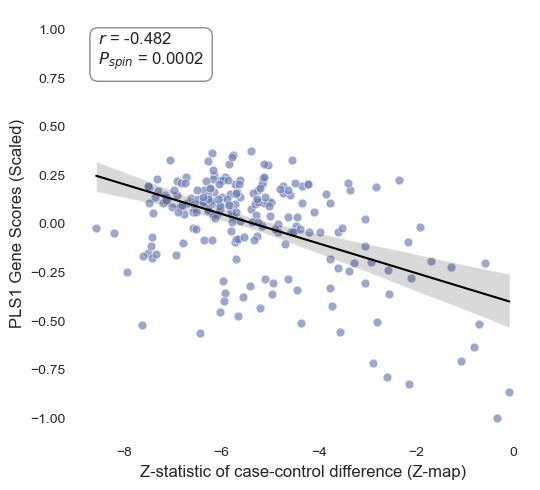

✅ 画图完成！相关系数 r = -0.4825，真实数据已通过 MaxAbs 缩放并完美展示在 [-1, 1] 之间。


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings

warnings.filterwarnings('ignore')

# =====================================
# 1. 加载数据
# =====================================
zmap_df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step18_Genetic/result1_zmap/subtype2_z_map.csv', header=None)
pls_df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step18_Genetic/result_Gene2_Correlation/subtype2/final_PLS_brain_regional_scores.csv')

# =====================================
# 2. 提取、对齐与【数据缩放】
# =====================================
z_values = zmap_df.iloc[:210, 1].values
pls1_scores_raw = pls_df['Comp1_Score'].values

# 🌟 核心数学转换：MaxAbs Scaling 把真实分数缩放到 [-1, 1] 之间
max_abs_val = np.nanmax(np.abs(pls1_scores_raw))
pls1_scores_scaled = pls1_scores_raw / max_abs_val

# 过滤 NaN
valid_mask = ~np.isnan(pls1_scores_scaled)
x_valid = z_values[valid_mask]
y_valid = pls1_scores_scaled[valid_mask] # 此时 y_valid 已经是 -1 到 1 之间的数据了

# 计算皮尔逊相关系数 (即使缩放，r 值绝对不变)
r_val, p_val = pearsonr(x_valid, y_valid)

# =====================================
# 3. 绘制精美散点图 (纯白背景)
# =====================================
# 明确指定画布背景色为纯白
fig = plt.figure(figsize=(5.5, 5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# 使用 seaborn 画图 (已修复 linewidths)
sns.regplot(
    x=x_valid,
    y=y_valid,
    scatter_kws={'alpha': 0.7, 'color': '#7382B8', 's': 40, 'edgecolor': 'white', 'linewidths': 0.5},
    line_kws={'color': 'black', 'linewidth': 1.5}
)

# 强制 Y 轴显示范围 (为了稍微美观一点，不让顶部的点被切掉一半，设置 -1.1 到 1.1，您也可以改成严格的 -1, 1)
plt.ylim(-1.1, 1.1)

# 在左上角添加统计文本
plt.text(
    0.05, 0.95,
    f'$r$ = {r_val:.3f}\n$P_{{spin}}$ = 0.0002',
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

# 设置标签和标题 (Y轴加上 Scaled 提示)
plt.xlabel('Z-statistic of case-control difference (Z-map)', fontsize=12, fontname='Arial')
plt.ylabel('PLS1 Gene Scores (Scaled)', fontsize=12, fontname='Arial')
#plt.title('Spatial Correlation: PLS1 vs Z-map', fontsize=14, fontname='Arial', pad=15)

# 优化边框和网格线
plt.grid(True, linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['left'].set_linewidth(1.2)
plt.tick_params(width=1.2)

# 紧凑布局并保存
plt.tight_layout()

# 保存时再次声明纯白背景，杜绝透明底
plt.savefig(
    '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step4_subtype/Step18_Genetic/result_Gene2_Correlation/subtype2/PLS1_vs_Zmap_Scatter_Final_Scaled.png',
    dpi=600,
    facecolor='white',
    transparent=False
)
plt.show()

print(f"✅ 画图完成！相关系数 r = {r_val:.4f}，真实数据已通过 MaxAbs 缩放并完美展示在 [-1, 1] 之间。")

数据分布，年龄

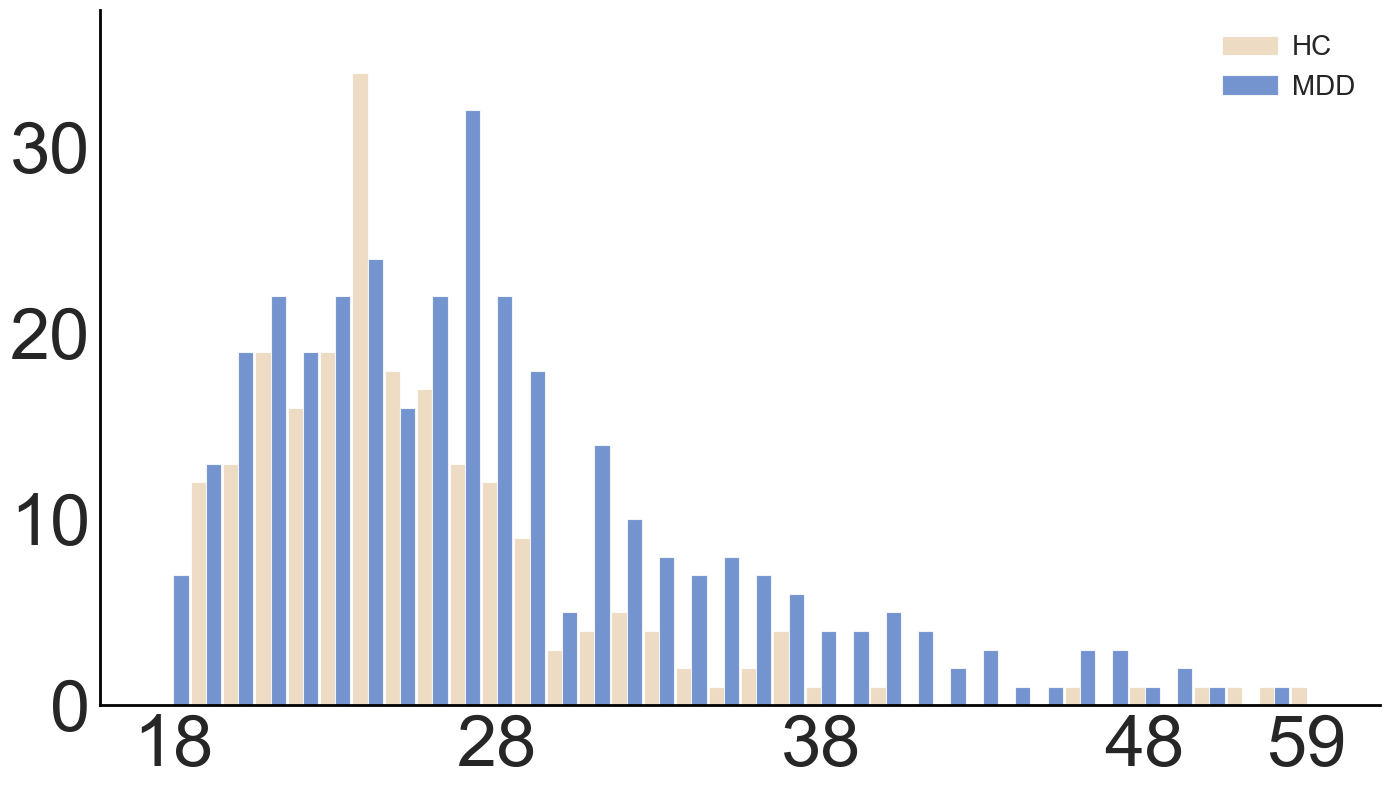

Done! Figure saved to:
 /Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/Data_age_MDDHC.png


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# 读取数据
hc_df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/HC_INT20_7net_agesex.csv', usecols=['age'])
mdd_df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/MDD_INT20_7net_agesex.csv', usecols=['age'])

# 提取年龄数据
hc_ages = hc_df['age'].dropna()  # 去除可能的空值
mdd_ages = mdd_df['age'].dropna()

# 统计年龄分布
hc_age_counts = Counter(hc_ages)
mdd_age_counts = Counter(mdd_ages)

# 确定所有年龄范围，用于统一x轴
all_ages = sorted(set(hc_ages) | set(mdd_ages))
hc_counts = [hc_age_counts.get(age, 0) for age in all_ages]
mdd_counts = [mdd_age_counts.get(age, 0) for age in all_ages]

# 设置柱状图宽度（加宽）和位置
bar_width = 0.47  # 更宽的柱子
x = np.arange(len(all_ages))

# 创建画布和子图，并设置透明背景
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')  # 设置画布背景为透明
ax.set_facecolor('white')         # 设置坐标轴背景为透明

# 绘制柱状图
bars1 = ax.bar(x - bar_width/2, hc_counts, bar_width, label='HC',
               color='#e9d4b5', alpha=0.8, edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + bar_width/2, mdd_counts, bar_width, label='MDD',
               color='#5079c4', alpha=0.8, edgecolor='white', linewidth=0.8)

# 设置图表标题和标签
ax.set_xlabel('', fontsize=24, fontfamily='Arial', labelpad=10)
ax.set_ylabel('', fontsize=24, fontfamily='Arial', labelpad=10)

# ==================== 动态适配 X 轴刻度 ====================
# 根据数据中实际年龄的最小值和最大值，动态计算 5 个等间距的年龄刻度
min_age = min(all_ages)
max_age = max(all_ages)
suggested_ages = np.linspace(min_age, max_age, 5, dtype=int)

target_indices = []
target_labels = []

# 在实际存在的 all_ages 中寻找与计算出的刻度最接近的年龄及索引
for age in suggested_ages:
    closest_idx = min(range(len(all_ages)), key=lambda i: abs(all_ages[i] - age))
    if closest_idx not in target_indices:
        target_indices.append(closest_idx)
        target_labels.append(str(all_ages[closest_idx]))

ax.set_xticks(target_indices)
ax.set_xticklabels(target_labels, fontsize=52)
# =========================================================

# 设置 y 轴字体大小
ax.tick_params(axis='y', labelsize=52)

# 设置 y 轴范围（动态留出 10% 的上方空间）
max_count = max(max(hc_counts) if hc_counts else 0, max(mdd_counts) if mdd_counts else 0)
ax.set_ylim(0, max_count * 1.1)

# 设置图表样式 - 确保轴线为黑色
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2.0)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# 添加图例，设置无边框无背景
legend = ax.legend(
    loc='upper right',
    fontsize=20,
    frameon=False,
    labelspacing=0.5,
    handletextpad=0.5
)

# 调整布局
plt.tight_layout()

# 保存
outpath = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/Step2_Ttest/Data_age_MDDHC.png'
plt.savefig(outpath, dpi=300)
plt.show()
plt.close()

print("Done! Figure saved to:\n", outpath)